# Synthetic Dataset
---
Creating synthetic training dataset for RC ConvFormer

Associated plots and RC-sorted synthetic arrays can be obtained upon request (mnronac@sandia.gov)

In [1]:
%%time
import warnings, random, os, sys
warnings.filterwarnings("ignore")
#-----------------------------------------------------------------------------------------------------------------#
# Import Cardinal
pwd = os.getcwd(); current_subdir = os.path.dirname(pwd)
sys.path.append(current_subdir); import cardinal
#-----------------------------------------------------------------------------------------------------------------#
# Command to make all plots interactive
%matplotlib ipympl
#-----------------------------------------------------------------------------------------------------------------#
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CPU times: user 9.07 s, sys: 6.48 s, total: 15.6 s
Wall time: 38.1 s


# Array response 
The array response is defined as
\begin{equation}\label{sig_power}
R(\omega, \pmb{k}) = \bigg| \frac{1}{N} \sum_{n=1}^N  e ^{-i \pmb{k}\cdot \pmb{r}_n} \bigg|^2.
\end{equation}

## Construct Frequency Bands
---

In [2]:
f_bands = cardinal.make_custom_fbands(f_min=0.02, f_max=21, type='octave')
f_bands

,band,fmin,fcenter,fmax,win,step
0,1.0,0.02,0.03,0.04,134.270734,13.427073
1,2.0,0.04,0.06,0.08,68.541468,6.854147
2,3.0,0.08,0.12,0.16,35.676835,3.567684
3,4.0,0.16,0.24,0.32,19.244519,1.924452
4,5.0,0.32,0.48,0.64,11.028360,1.102836
5,6.0,0.64,0.96,1.28,6.920281,0.692028
6,7.0,1.28,1.92,2.56,4.866242,0.486624
7,8.0,2.56,3.84,5.12,3.839222,0.383922
8,9.0,5.12,7.68,10.24,3.325712,0.332571
9,10.0,10.24,15.36,20.48,3.068957,0.306896


## Generate Array Response Functions using Synthetic Arrays for Infrasound
---
Aggregate mean, standard deviation, and max for Response Criterion (RC)

In [5]:
%%time
training_sample = 100001
while training_sample < 250000:
    # Randomly choose freq band
    band_idx = random.sample(range(len(f_bands)), 1)[0]
    freqmin = f_bands.iloc[band_idx]['fmin']; freqmax = f_bands.iloc[band_idx]['fmax']
    #-----------------------------------------------------------------------------------------------------------------#
    # Generate synthetic array
    small_arr_extent = 0.2; large_arr_extent = 5 # 0.2x0.2 km grid for small and 5x5km grid for large
    geometry, relative_geometry, arr_labels = cardinal.make_synthetic_array(num_stns=10, small_arr_extent=small_arr_extent, large_arr_extent=large_arr_extent) # outputs in meters
    #-----------------------------------------------------------------------------------------------------------------#
    # Plot array coordinates
    plt.ioff()
    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(1,2,1)
    ax1.plot(relative_geometry[:,0], relative_geometry[:,1], '.')
    for i in range(0,len(arr_labels)):
        plt.text(relative_geometry[i,0], relative_geometry[i,1], arr_labels[i])
    plt.xlabel('X (m)'); plt.ylabel('Y (m)'); plt.title('Synthetic Array')
    plt.xlim([-large_arr_extent*1000,large_arr_extent*1000]); plt.ylim([-large_arr_extent*1000,large_arr_extent*1000]); plt.grid(linewidth=0.25)
    #-----------------------------------------------------------------------------------------------------------------#
    # Generate array response and measure mean/std
    ax2 = fig.add_subplot(1,2,2)
    array_resp, p_x, p_y, array_resp_max = cardinal.array_response(relative_geometry[:,0], relative_geometry[:,1], freqmin=freqmin, freqmax=freqmax, c_app=340, c_steps=200, freqsteps=50)
    mean_tmp = np.mean(array_resp); std_tmp = np.std(array_resp)
    ax2.pcolormesh(p_x, p_y, array_resp, cmap='viridis')
    cs = ax2.contourf(p_x, p_y, array_resp, levels=np.arange(0.1, 1+0.05, 0.05), cmap='viridis')
    cbar = plt.colorbar(cs); cbar.set_label('Power', fontsize=12)
    plt.xlabel(r'$U_{x}$'); plt.ylabel(r'$U_{y}$')
    plt.xlim([-0.003,0.003]); plt.ylim([-0.003,0.003])
    plt.title('Freq. Range: %.2f'%freqmin + ' to %.2f'%freqmax + ' Hz\nMax: %.3f'%array_resp_max + ' - Mean: %.3f'%mean_tmp + ' - Std: %.3f'%std_tmp)
    #-----------------------------------------------------------------------------------------------------------------#
    # Saving plot
    plt.savefig('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Plots/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_config')
    plt.close()
    #-----------------------------------------------------------------------------------------------------------------#
    # Storing params (geometry, relative_geometry, freqmin, freqmax, array_resp, mean, std)
    np.save('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_geometry.npy', geometry)
    np.save('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_relative_geometry.npy', relative_geometry)
    np.save('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_freqmin.npy', freqmin)
    np.save('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_freqmax.npy', freqmax)
    np.save('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_array_resp.npy', array_resp)
    np.save('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_mean.npy', mean_tmp)
    np.save('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_std.npy', std_tmp)
    np.save('Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_max.npy', array_resp_max)
    #-----------------------------------------------------------------------------------------------------------------#
    # Keeping track of total number of training samples
    print('Done with sample ' + str(training_sample+1) + ' in band '+ str(band_idx+1))
    training_sample += 1 

Done with sample 100002 in band 10
Done with sample 100003 in band 5
Done with sample 100004 in band 9
Done with sample 100005 in band 8
Done with sample 100006 in band 2
Done with sample 100007 in band 5
Done with sample 100008 in band 6
Done with sample 100009 in band 8
Done with sample 100010 in band 1
Done with sample 100011 in band 5
Done with sample 100012 in band 5
Done with sample 100013 in band 9
Done with sample 100014 in band 4
Done with sample 100015 in band 1
Done with sample 100016 in band 9
Done with sample 100017 in band 7
Done with sample 100018 in band 1
Done with sample 100019 in band 2
Done with sample 100020 in band 3
Done with sample 100021 in band 8
Done with sample 100022 in band 3
Done with sample 100023 in band 7
Done with sample 100024 in band 2
Done with sample 100025 in band 9
Done with sample 100026 in band 1
Done with sample 100027 in band 2
Done with sample 100028 in band 1
Done with sample 100029 in band 8
Done with sample 100030 in band 4
Done with sam

Done with sample 100243 in band 8
Done with sample 100244 in band 6
Done with sample 100245 in band 6
Done with sample 100246 in band 10
Done with sample 100247 in band 10
Done with sample 100248 in band 3
Done with sample 100249 in band 7
Done with sample 100250 in band 8
Done with sample 100251 in band 4
Done with sample 100252 in band 5
Done with sample 100253 in band 1
Done with sample 100254 in band 4
Done with sample 100255 in band 5
Done with sample 100256 in band 2
Done with sample 100257 in band 9
Done with sample 100258 in band 3
Done with sample 100259 in band 4
Done with sample 100260 in band 5
Done with sample 100261 in band 7
Done with sample 100262 in band 4
Done with sample 100263 in band 9
Done with sample 100264 in band 9
Done with sample 100265 in band 9
Done with sample 100266 in band 4
Done with sample 100267 in band 2
Done with sample 100268 in band 5
Done with sample 100269 in band 3
Done with sample 100270 in band 1
Done with sample 100271 in band 1
Done with sa

Done with sample 100484 in band 10
Done with sample 100485 in band 9
Done with sample 100486 in band 10
Done with sample 100487 in band 9
Done with sample 100488 in band 8
Done with sample 100489 in band 4
Done with sample 100490 in band 4
Done with sample 100491 in band 10
Done with sample 100492 in band 2
Done with sample 100493 in band 7
Done with sample 100494 in band 1
Done with sample 100495 in band 2
Done with sample 100496 in band 3
Done with sample 100497 in band 8
Done with sample 100498 in band 4
Done with sample 100499 in band 4
Done with sample 100500 in band 10
Done with sample 100501 in band 7
Done with sample 100502 in band 1
Done with sample 100503 in band 9
Done with sample 100504 in band 4
Done with sample 100505 in band 10
Done with sample 100506 in band 3
Done with sample 100507 in band 6
Done with sample 100508 in band 5
Done with sample 100509 in band 7
Done with sample 100510 in band 7
Done with sample 100511 in band 6
Done with sample 100512 in band 10
Done wit

Done with sample 100725 in band 3
Done with sample 100726 in band 10
Done with sample 100727 in band 5
Done with sample 100728 in band 2
Done with sample 100729 in band 3
Done with sample 100730 in band 9
Done with sample 100731 in band 7
Done with sample 100732 in band 10
Done with sample 100733 in band 6
Done with sample 100734 in band 1
Done with sample 100735 in band 6
Done with sample 100736 in band 9
Done with sample 100737 in band 1
Done with sample 100738 in band 4
Done with sample 100739 in band 9
Done with sample 100740 in band 10
Done with sample 100741 in band 7
Done with sample 100742 in band 2
Done with sample 100743 in band 10
Done with sample 100744 in band 1
Done with sample 100745 in band 1
Done with sample 100746 in band 8
Done with sample 100747 in band 3
Done with sample 100748 in band 5
Done with sample 100749 in band 8
Done with sample 100750 in band 3
Done with sample 100751 in band 10
Done with sample 100752 in band 3
Done with sample 100753 in band 6
Done with

Done with sample 100966 in band 1
Done with sample 100967 in band 5
Done with sample 100968 in band 3
Done with sample 100969 in band 2
Done with sample 100970 in band 2
Done with sample 100971 in band 3
Done with sample 100972 in band 8
Done with sample 100973 in band 4
Done with sample 100974 in band 4
Done with sample 100975 in band 7
Done with sample 100976 in band 10
Done with sample 100977 in band 8
Done with sample 100978 in band 9
Done with sample 100979 in band 8
Done with sample 100980 in band 10
Done with sample 100981 in band 3
Done with sample 100982 in band 10
Done with sample 100983 in band 8
Done with sample 100984 in band 1
Done with sample 100985 in band 5
Done with sample 100986 in band 5
Done with sample 100987 in band 2
Done with sample 100988 in band 4
Done with sample 100989 in band 6
Done with sample 100990 in band 9
Done with sample 100991 in band 7
Done with sample 100992 in band 6
Done with sample 100993 in band 5
Done with sample 100994 in band 9
Done with s

...

Done with sample 248914 in band 1
Done with sample 248915 in band 10
Done with sample 248916 in band 9
Done with sample 248917 in band 2
Done with sample 248918 in band 1
Done with sample 248919 in band 2
Done with sample 248920 in band 1
Done with sample 248921 in band 7
Done with sample 248922 in band 9
Done with sample 248923 in band 9
Done with sample 248924 in band 9
Done with sample 248925 in band 5
Done with sample 248926 in band 7
Done with sample 248927 in band 7
Done with sample 248928 in band 5
Done with sample 248929 in band 1
Done with sample 248930 in band 4
Done with sample 248931 in band 7
Done with sample 248932 in band 6
Done with sample 248933 in band 2
Done with sample 248934 in band 1
Done with sample 248935 in band 2
Done with sample 248936 in band 10
Done with sample 248937 in band 7
Done with sample 248938 in band 3
Done with sample 248939 in band 2
Done with sample 248940 in band 3
Done with sample 248941 in band 2
Done with sample 248942 in band 1
Done with sa

Done with sample 249155 in band 5
Done with sample 249156 in band 9
Done with sample 249157 in band 10
Done with sample 249158 in band 8
Done with sample 249159 in band 1
Done with sample 249160 in band 4
Done with sample 249161 in band 5
Done with sample 249162 in band 8
Done with sample 249163 in band 5
Done with sample 249164 in band 4
Done with sample 249165 in band 6
Done with sample 249166 in band 10
Done with sample 249167 in band 8
Done with sample 249168 in band 9
Done with sample 249169 in band 2
Done with sample 249170 in band 2
Done with sample 249171 in band 5
Done with sample 249172 in band 3
Done with sample 249173 in band 1
Done with sample 249174 in band 10
Done with sample 249175 in band 3
Done with sample 249176 in band 2
Done with sample 249177 in band 8
Done with sample 249178 in band 5
Done with sample 249179 in band 7
Done with sample 249180 in band 9
Done with sample 249181 in band 1
Done with sample 249182 in band 1
Done with sample 249183 in band 1
Done with s

Done with sample 249396 in band 8
Done with sample 249397 in band 1
Done with sample 249398 in band 10
Done with sample 249399 in band 5
Done with sample 249400 in band 9
Done with sample 249401 in band 9
Done with sample 249402 in band 10
Done with sample 249403 in band 2
Done with sample 249404 in band 5
Done with sample 249405 in band 7
Done with sample 249406 in band 6
Done with sample 249407 in band 8
Done with sample 249408 in band 7
Done with sample 249409 in band 2
Done with sample 249410 in band 9
Done with sample 249411 in band 7
Done with sample 249412 in band 8
Done with sample 249413 in band 5
Done with sample 249414 in band 6
Done with sample 249415 in band 2
Done with sample 249416 in band 8
Done with sample 249417 in band 10
Done with sample 249418 in band 10
Done with sample 249419 in band 7
Done with sample 249420 in band 2
Done with sample 249421 in band 10
Done with sample 249422 in band 6
Done with sample 249423 in band 9
Done with sample 249424 in band 3
Done with

Done with sample 249637 in band 4
Done with sample 249638 in band 7
Done with sample 249639 in band 5
Done with sample 249640 in band 10
Done with sample 249641 in band 1
Done with sample 249642 in band 10
Done with sample 249643 in band 2
Done with sample 249644 in band 5
Done with sample 249645 in band 10
Done with sample 249646 in band 6
Done with sample 249647 in band 7
Done with sample 249648 in band 6
Done with sample 249649 in band 8
Done with sample 249650 in band 8
Done with sample 249651 in band 8
Done with sample 249652 in band 10
Done with sample 249653 in band 5
Done with sample 249654 in band 2
Done with sample 249655 in band 10
Done with sample 249656 in band 9
Done with sample 249657 in band 9
Done with sample 249658 in band 9
Done with sample 249659 in band 9
Done with sample 249660 in band 10
Done with sample 249661 in band 9
Done with sample 249662 in band 2
Done with sample 249663 in band 3
Done with sample 249664 in band 7
Done with sample 249665 in band 3
Done wit

Done with sample 249878 in band 2
Done with sample 249879 in band 7
Done with sample 249880 in band 1
Done with sample 249881 in band 6
Done with sample 249882 in band 3
Done with sample 249883 in band 2
Done with sample 249884 in band 4
Done with sample 249885 in band 10
Done with sample 249886 in band 3
Done with sample 249887 in band 4
Done with sample 249888 in band 6
Done with sample 249889 in band 2
Done with sample 249890 in band 8
Done with sample 249891 in band 8
Done with sample 249892 in band 6
Done with sample 249893 in band 8
Done with sample 249894 in band 2
Done with sample 249895 in band 7
Done with sample 249896 in band 9
Done with sample 249897 in band 2
Done with sample 249898 in band 4
Done with sample 249899 in band 2
Done with sample 249900 in band 1
Done with sample 249901 in band 9
Done with sample 249902 in band 3
Done with sample 249903 in band 5
Done with sample 249904 in band 1
Done with sample 249905 in band 8
Done with sample 249906 in band 10
Done with sa

## Generate Array Response Functions using Synthetic Arrays for Seismic
---
Aggregate mean, standard deviation, and max for Response Criterion (RC)

In [ ]:
# %%time
training_sample = 0
while training_sample < 125000:
    # Randomly choose freq band
    band_idx = random.sample(range(len(f_bands)), 1)[0]
    freqmin = f_bands.iloc[band_idx]['fmin']; freqmax = f_bands.iloc[band_idx]['fmax']
    #-----------------------------------------------------------------------------------------------------------------#
    # Generate synthetic array
    small_arr_extent = 2; large_arr_extent = 50 # 2x2 km grid for small and 50x50km grid for large (1 order of magnitude larger than infrasound)
    geometry, relative_geometry, arr_labels = cardinal.make_synthetic_array(num_stns=10, small_arr_extent=small_arr_extent, large_arr_extent=large_arr_extent) # outputs in meters
    #-----------------------------------------------------------------------------------------------------------------#
    # Generate array response and measure mean/std
    array_resp, p_x, p_y, array_resp_max = cardinal.array_response(relative_geometry[:,0], relative_geometry[:,1], freqmin=freqmin, freqmax=freqmax, c_app=3000, c_steps=200, freqsteps=50)
    mean_tmp = np.mean(array_resp); std_tmp = np.std(array_resp)
    #-----------------------------------------------------------------------------------------------------------------#
    # Storing params (geometry, relative_geometry, freqmin, freqmax, array_resp, mean, std)
    np.save('/Volumes/My Passport/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_geometry.npy', geometry)
    np.save('/Volumes/My Passport/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_relative_geometry.npy', relative_geometry)
    np.save('/Volumes/My Passport/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_freqmin.npy', freqmin)
    np.save('/Volumes/My Passport/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_freqmax.npy', freqmax)
    np.save('/Volumes/My Passport/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_array_resp.npy', array_resp)
    np.save('/Volumes/My Passport/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_mean.npy', mean_tmp)
    np.save('/Volumes/My Passport/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_std.npy', std_tmp)
    np.save('/Volumes/My Passport/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_max.npy', array_resp_max)
    #-----------------------------------------------------------------------------------------------------------------#
    # Keeping track of total number of training samples
    print('Done with sample ' + str(training_sample+1) + ' in band '+ str(band_idx+1))
    training_sample += 1 

Done with sample 1 in band 8
Done with sample 2 in band 7
Done with sample 3 in band 3
Done with sample 4 in band 7
Done with sample 5 in band 10
Done with sample 6 in band 1
Done with sample 7 in band 1
Done with sample 8 in band 3
Done with sample 9 in band 2
Done with sample 10 in band 3
Done with sample 11 in band 1
Done with sample 12 in band 6
Done with sample 13 in band 10
Done with sample 14 in band 8
Done with sample 15 in band 7
Done with sample 16 in band 10
Done with sample 17 in band 1
Done with sample 18 in band 6
Done with sample 19 in band 2
Done with sample 20 in band 5
Done with sample 21 in band 8
Done with sample 22 in band 7
Done with sample 23 in band 8
Done with sample 24 in band 1
Done with sample 25 in band 5
Done with sample 26 in band 10
Done with sample 27 in band 8
Done with sample 28 in band 10
Done with sample 29 in band 9
Done with sample 30 in band 9
Done with sample 31 in band 6
Done with sample 32 in band 2
Done with sample 33 in band 3
Done with samp

Done with sample 270 in band 3
Done with sample 271 in band 4
Done with sample 272 in band 5
Done with sample 273 in band 8
Done with sample 274 in band 4
Done with sample 275 in band 7
Done with sample 276 in band 5
Done with sample 277 in band 6
Done with sample 278 in band 7
Done with sample 279 in band 6
Done with sample 280 in band 4
Done with sample 281 in band 9
Done with sample 282 in band 3
Done with sample 283 in band 7
Done with sample 284 in band 2
Done with sample 285 in band 10
Done with sample 286 in band 2
Done with sample 287 in band 5
Done with sample 288 in band 7
Done with sample 289 in band 3
Done with sample 290 in band 10
Done with sample 291 in band 6
Done with sample 292 in band 8
Done with sample 293 in band 7
Done with sample 294 in band 1
Done with sample 295 in band 1
Done with sample 296 in band 2
Done with sample 297 in band 4
Done with sample 298 in band 8
Done with sample 299 in band 8
Done with sample 300 in band 7
Done with sample 301 in band 4
Done w

Done with sample 534 in band 7
Done with sample 535 in band 6
Done with sample 536 in band 8
Done with sample 537 in band 1
Done with sample 538 in band 1
Done with sample 539 in band 8
Done with sample 540 in band 5
Done with sample 541 in band 5
Done with sample 542 in band 6
Done with sample 543 in band 3
Done with sample 544 in band 9
Done with sample 545 in band 2
Done with sample 546 in band 3
Done with sample 547 in band 5
Done with sample 548 in band 5
Done with sample 549 in band 3
Done with sample 550 in band 6
Done with sample 551 in band 2
Done with sample 552 in band 8
Done with sample 553 in band 2
Done with sample 554 in band 10
Done with sample 555 in band 1
Done with sample 556 in band 4
Done with sample 557 in band 6
Done with sample 558 in band 8
Done with sample 559 in band 7
Done with sample 560 in band 8
Done with sample 561 in band 6
Done with sample 562 in band 1
Done with sample 563 in band 6
Done with sample 564 in band 9
Done with sample 565 in band 4
Done wi

Done with sample 799 in band 7
Done with sample 800 in band 5
Done with sample 801 in band 7
Done with sample 802 in band 9
Done with sample 803 in band 8
Done with sample 804 in band 8
Done with sample 805 in band 3
Done with sample 806 in band 10
Done with sample 807 in band 2
Done with sample 808 in band 2
Done with sample 809 in band 1
Done with sample 810 in band 3
Done with sample 811 in band 5
Done with sample 812 in band 1
Done with sample 813 in band 9
Done with sample 814 in band 10
Done with sample 815 in band 7
Done with sample 816 in band 3
Done with sample 817 in band 5
Done with sample 818 in band 2
Done with sample 819 in band 2
Done with sample 820 in band 8
Done with sample 821 in band 6
Done with sample 822 in band 7
Done with sample 823 in band 6
Done with sample 824 in band 8
Done with sample 825 in band 1
Done with sample 826 in band 8
Done with sample 827 in band 2
Done with sample 828 in band 1
Done with sample 829 in band 6
Done with sample 830 in band 6
Done w

Done with sample 1062 in band 5
Done with sample 1063 in band 8
Done with sample 1064 in band 6
Done with sample 1065 in band 6
Done with sample 1066 in band 4
Done with sample 1067 in band 9
Done with sample 1068 in band 7
Done with sample 1069 in band 2
Done with sample 1070 in band 5
Done with sample 1071 in band 6
Done with sample 1072 in band 10
Done with sample 1073 in band 7
Done with sample 1074 in band 9
Done with sample 1075 in band 4
Done with sample 1076 in band 8
Done with sample 1077 in band 2
Done with sample 1078 in band 6
Done with sample 1079 in band 9
Done with sample 1080 in band 4
Done with sample 1081 in band 3
Done with sample 1082 in band 4
Done with sample 1083 in band 2
Done with sample 1084 in band 8
Done with sample 1085 in band 3
Done with sample 1086 in band 9
Done with sample 1087 in band 7
Done with sample 1088 in band 1
Done with sample 1089 in band 2
Done with sample 1090 in band 5
Done with sample 1091 in band 2
Done with sample 1092 in band 2
Done wi

...

Done with sample 23185 in band 1
Done with sample 23186 in band 8
Done with sample 23187 in band 1
Done with sample 23188 in band 10
Done with sample 23189 in band 10
Done with sample 23190 in band 2
Done with sample 23191 in band 3
Done with sample 23192 in band 6
Done with sample 23193 in band 1
Done with sample 23194 in band 8
Done with sample 23195 in band 7
Done with sample 23196 in band 2
Done with sample 23197 in band 4
Done with sample 23198 in band 8
Done with sample 23199 in band 2
Done with sample 23200 in band 7
Done with sample 23201 in band 7
Done with sample 23202 in band 9
Done with sample 23203 in band 7
Done with sample 23204 in band 9
Done with sample 23205 in band 7
Done with sample 23206 in band 2
Done with sample 23207 in band 10
Done with sample 23208 in band 6
Done with sample 23209 in band 9
Done with sample 23210 in band 5
Done with sample 23211 in band 9
Done with sample 23212 in band 2
Done with sample 23213 in band 1
Done with sample 23214 in band 3
Done wi

Done with sample 23433 in band 7
Done with sample 23434 in band 5
Done with sample 23435 in band 9
Done with sample 23436 in band 8
Done with sample 23437 in band 6
Done with sample 23438 in band 6
Done with sample 23439 in band 5
Done with sample 23440 in band 6
Done with sample 23441 in band 1
Done with sample 23442 in band 5
Done with sample 23443 in band 5
Done with sample 23444 in band 8
Done with sample 23445 in band 9
Done with sample 23446 in band 10
Done with sample 23447 in band 9
Done with sample 23448 in band 4
Done with sample 23449 in band 6
Done with sample 23450 in band 3
Done with sample 23451 in band 1
Done with sample 23452 in band 9
Done with sample 23453 in band 6
Done with sample 23454 in band 7
Done with sample 23455 in band 8
Done with sample 23456 in band 10
Done with sample 23457 in band 9
Done with sample 23458 in band 7
Done with sample 23459 in band 6
Done with sample 23460 in band 1
Done with sample 23461 in band 10
Done with sample 23462 in band 7
Done wi

Done with sample 23681 in band 7
Done with sample 23682 in band 6
Done with sample 23683 in band 5
Done with sample 23684 in band 2
Done with sample 23685 in band 7
Done with sample 23686 in band 8
Done with sample 23687 in band 9
Done with sample 23688 in band 10
Done with sample 23689 in band 2
Done with sample 23690 in band 7
Done with sample 23691 in band 5
Done with sample 23692 in band 8
Done with sample 23693 in band 6
Done with sample 23694 in band 9
Done with sample 23695 in band 9
Done with sample 23696 in band 5
Done with sample 23697 in band 5
Done with sample 23698 in band 5
Done with sample 23699 in band 1
Done with sample 23700 in band 2
Done with sample 23701 in band 5
Done with sample 23702 in band 2
Done with sample 23703 in band 3
Done with sample 23704 in band 6
Done with sample 23705 in band 1
Done with sample 23706 in band 3
Done with sample 23707 in band 1
Done with sample 23708 in band 5
Done with sample 23709 in band 3
Done with sample 23710 in band 8
Done with

Done with sample 23930 in band 10
Done with sample 23931 in band 2
Done with sample 23932 in band 2
Done with sample 23933 in band 2
Done with sample 23934 in band 9
Done with sample 23935 in band 10
Done with sample 23936 in band 7
Done with sample 23937 in band 2
Done with sample 23938 in band 8
Done with sample 23939 in band 7
Done with sample 23940 in band 7
Done with sample 23941 in band 2
Done with sample 23942 in band 7
Done with sample 23943 in band 10
Done with sample 23944 in band 4
Done with sample 23945 in band 10
Done with sample 23946 in band 4
Done with sample 23947 in band 7
Done with sample 23948 in band 6
Done with sample 23949 in band 1
Done with sample 23950 in band 4
Done with sample 23951 in band 10
Done with sample 23952 in band 9
Done with sample 23953 in band 9
Done with sample 23954 in band 1
Done with sample 23955 in band 2
Done with sample 23956 in band 4
Done with sample 23957 in band 8
Done with sample 23958 in band 9
Done with sample 23959 in band 4
Done 

Done with sample 24178 in band 9
Done with sample 24179 in band 6
Done with sample 24180 in band 10
Done with sample 24181 in band 6
Done with sample 24182 in band 10
Done with sample 24183 in band 6
Done with sample 24184 in band 9
Done with sample 24185 in band 7
Done with sample 24186 in band 8
Done with sample 24187 in band 4
Done with sample 24188 in band 5
Done with sample 24189 in band 1
Done with sample 24190 in band 3
Done with sample 24191 in band 9
Done with sample 24192 in band 6
Done with sample 24193 in band 9
Done with sample 24194 in band 6
Done with sample 24195 in band 10
Done with sample 24196 in band 8
Done with sample 24197 in band 7
Done with sample 24198 in band 2
Done with sample 24199 in band 4
Done with sample 24200 in band 7
Done with sample 24201 in band 1
Done with sample 24202 in band 10
Done with sample 24203 in band 3
Done with sample 24204 in band 1
Done with sample 24205 in band 6
Done with sample 24206 in band 7
Done with sample 24207 in band 3
Done w

In [9]:
%%time
training_sample = 235059
while training_sample <= 250000:
    # Randomly choose freq band
    band_idx = random.sample(range(len(f_bands)), 1)[0]
    freqmin = f_bands.iloc[band_idx]['fmin']; freqmax = f_bands.iloc[band_idx]['fmax']
    #-----------------------------------------------------------------------------------------------------------------#
    # Generate synthetic array
    small_arr_extent = 2; large_arr_extent = 50 # 2x2 km grid for small and 50x50km grid for large (1 order of magnitude larger than infrasound)
    geometry, relative_geometry, arr_labels = cardinal.make_synthetic_array(num_stns=10, small_arr_extent=small_arr_extent, large_arr_extent=large_arr_extent) # outputs in meters
    #-----------------------------------------------------------------------------------------------------------------#
    # Generate array response and measure mean/std
    array_resp, p_x, p_y, array_resp_max = cardinal.array_response(relative_geometry[:,0], relative_geometry[:,1], freqmin=freqmin, freqmax=freqmax, c_app=3000, c_steps=200, freqsteps=50)
    mean_tmp = np.mean(array_resp); std_tmp = np.std(array_resp)
    #-----------------------------------------------------------------------------------------------------------------#
    # Storing params (geometry, relative_geometry, freqmin, freqmax, array_resp, mean, std)
    np.save('/Volumes/Extreme SSD/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_geometry.npy', geometry)
    np.save('/Volumes/Extreme SSD/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_relative_geometry.npy', relative_geometry)
    np.save('/Volumes/Extreme SSD/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_freqmin.npy', freqmin)
    np.save('/Volumes/Extreme SSD/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_freqmax.npy', freqmax)
    np.save('/Volumes/Extreme SSD/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_array_resp.npy', array_resp)
    np.save('/Volumes/Extreme SSD/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_mean.npy', mean_tmp)
    np.save('/Volumes/Extreme SSD/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_std.npy', std_tmp)
    np.save('/Volumes/Extreme SSD/RC_ConvFormer/Synthetic_Arrays/Band_'+str(band_idx+1)+'/Data/'+str(training_sample)+'_'+'_'.join(arr_labels)+'_max.npy', array_resp_max)
    #-----------------------------------------------------------------------------------------------------------------#
    # Keeping track of total number of training samples
    print('Done with sample ' + str(training_sample+1) + ' in band '+ str(band_idx+1))
    training_sample += 1 

---
Generate synthetic array function

In [4]:
def make_synthetic_array(num_stns=10, small_arr_extent=0.2, large_arr_extent=5, randomize=True):
    '''---------------------------------------------------------------------------------------------------------
    Generates synthetic multi-scale array with elements randomly distributed across 2 different scaled grids

    Input:
        num_stns (int): number of stations contained in the synthetic array
        small_arr_extent (float/int): extent of small-scale grid (central elements)
        large_arr_extent (float/int): extent of large-scale grid (outer elements)
        randomize (boolean): whether to randomly shuffle array elements
    
    Output:
        new_geometry (array): geometry of synthetic array (in m)
        relative_geometry (array): geometry of synthetic array relative to a randomly selected reference element (in m)
        new_arr_labels (list): list of element names (numeric values = central elements and alphabetic values = outer elements)
    ---------------------------------------------------------------------------------------------------------'''
    # Make small array
    x_extent_small = small_arr_extent/2; y_extent_small = x_extent_small
    x_small = [random.uniform(-x_extent_small, x_extent_small) for _ in range(num_stns//2)]
    y_small = [random.uniform(-y_extent_small, y_extent_small) for _ in range(num_stns//2)]
    geometry_small = np.hstack((x_small, y_small)).reshape(len(x_small),2)
    #-----------------------------------------------------------------------------------------------------------------#
    # Make large array
    x_extent_large = large_arr_extent/2; y_extent_large = x_extent_large
    x_large = [random.uniform(-x_extent_large, x_extent_large) for _ in range(num_stns//2)]
    y_large = [random.uniform(-y_extent_large, y_extent_large) for _ in range(num_stns//2)]
    geometry_large = np.hstack((x_large, y_large)).reshape(len(x_large),2)
    #-----------------------------------------------------------------------------------------------------------------#
    # Combine arrays
    geometry = np.vstack((geometry_small, geometry_large))
    synthetic_arr_labels = np.array(['S1', 'S2', 'S3', 'S4', 'S5', 'SA', 'SB', 'SC', 'SD', 'SE']) # numeric = small...alphabetic = large
    rand_num_stns = random.sample(range(3, len(synthetic_arr_labels)-2), 1)[0] # randomly choose number of elements to incorporate
    rand_num_stns_idxs = random.sample(range(len(synthetic_arr_labels)), rand_num_stns)
    #-----------------------------------------------------------------------------------------------------------------#
    # Construct subarray
    if randomize == True:
        new_geometry = geometry[rand_num_stns_idxs,:]
        new_arr_labels = synthetic_arr_labels[rand_num_stns_idxs]
    else:
        new_geometry = geometry.copy()
        new_arr_labels = synthetic_arr_labels.copy()
    #-----------------------------------------------------------------------------------------------------------------#
    # Relative coordinates based on randomly chosen reference station
    rand_stn_idx = random.sample(range(new_geometry.shape[0]), 1)[0]
    ref_station = new_arr_labels[rand_stn_idx]
    ref_station_ix = np.where(new_arr_labels == ref_station)[0][0]
    relative_geometry = np.zeros((new_geometry.shape))
    relative_geometry[:,0] = (new_geometry[:,0] - new_geometry[ref_station_ix,0])
    relative_geometry[:,1] = (new_geometry[:,1] - new_geometry[ref_station_ix,1])
    new_geometry *= 1000; relative_geometry *= 1000 # convert to meters
    #-----------------------------------------------------------------------------------------------------------------#
    # Return geometry, relative geometry, and labels
    return new_geometry, relative_geometry, new_arr_labels

---
Infrasound Example

Text(0.5, 1.0, 'Freq. Range: 0.32 to 0.64 Hz\nRC: 7.305e-05')

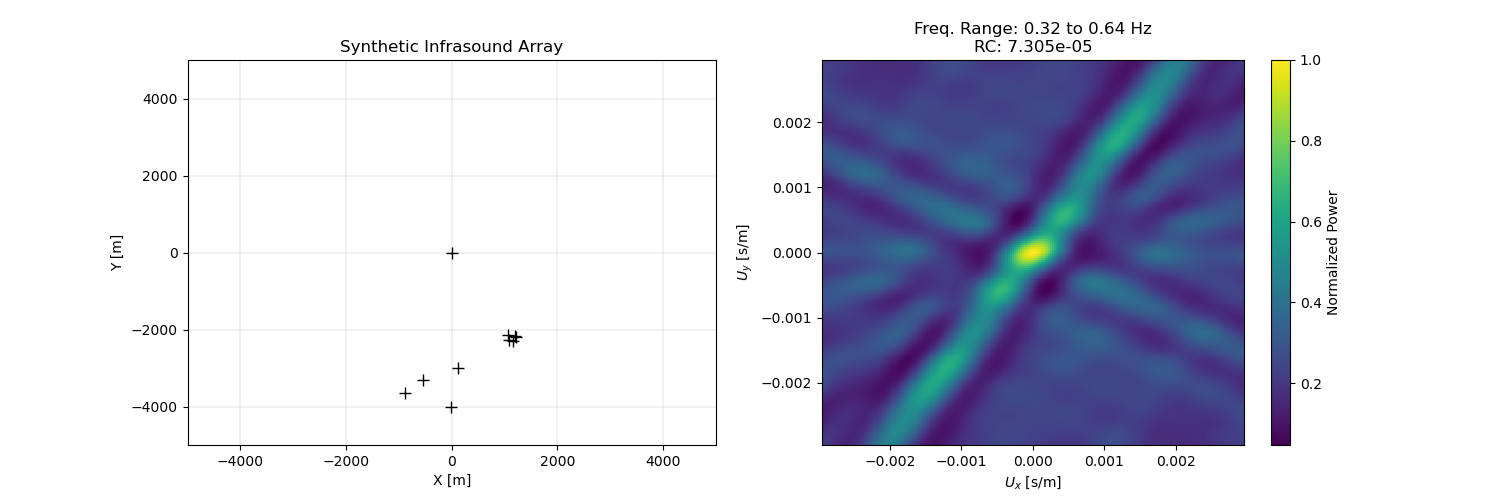

In [37]:
freqmin = 0.32; freqmax=0.64
geometry, relative_geometry, labels = make_synthetic_array(randomize=False, num_stns=10)
array_resp, p_x, p_y, array_resp_max = cardinal.array_response(relative_geometry[:,0], relative_geometry[:,1], freqmin=freqmin, freqmax=freqmax, c_app=340, c_steps=200, freqsteps=50)
#-----------------------------------------------------------------------------------------------------------------#
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(relative_geometry[:,0], relative_geometry[:,1], '+', color='black', markersize=8)
axs[0].set_title('Synthetic Infrasound Array')
axs[0].set_xlabel('X [m]'); axs[0].set_ylabel('Y [m]')
axs[0].set_xlim([-5000,5000]); axs[0].set_ylim([-5000,5000])
axs[0].grid(lw=0.25)
# Plot array response
pcolor = axs[1].pcolormesh(p_x, p_y, array_resp, cmap='viridis')
cbar = plt.colorbar(pcolor, label='Normalized Power')
axs[1].set_xlabel(r'$U_{x}$ [s/m]'); axs[1].set_ylabel(r'$U_{y}$ [s/m]')
mean_tmp = np.mean(array_resp); std_tmp = np.std(array_resp)
plt.title('Freq. Range: %.2f'%freqmin + ' to %.2f'%freqmax + ' Hz\nRC: '+ format(((mean_tmp + std_tmp) / array_resp_max), ".3e"))

Text(0.5, 1.0, 'Freq. Range: 0.32 to 0.64 Hz\nRC: 7.555e-05')

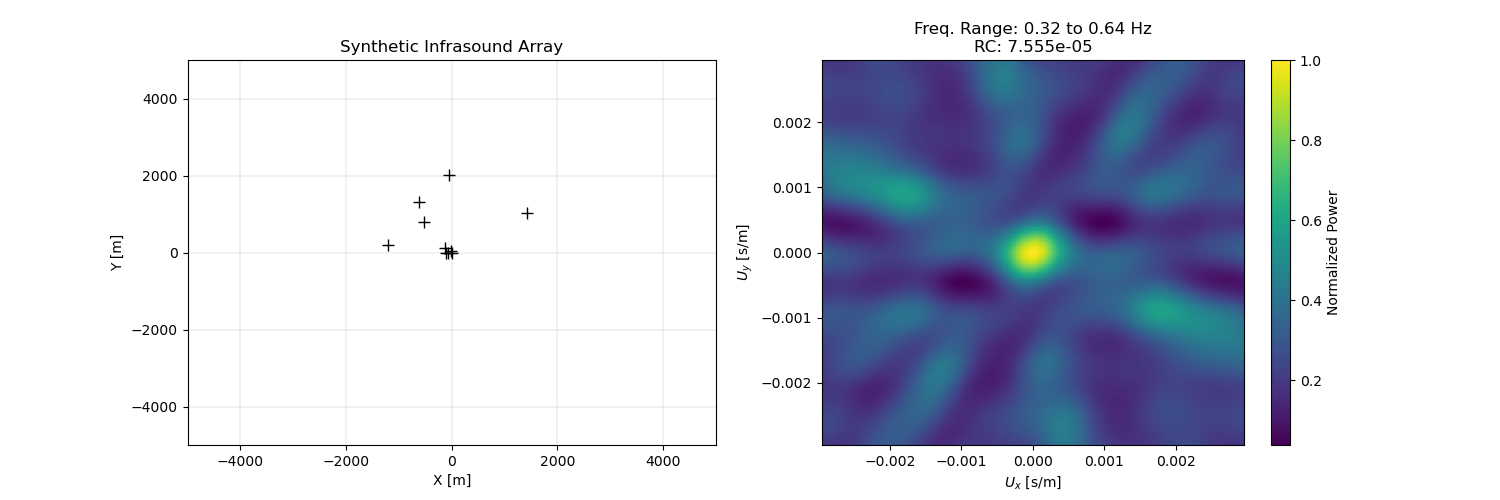

In [53]:
freqmin = 0.32; freqmax=0.64
geometry, relative_geometry, labels = make_synthetic_array(randomize=False, num_stns=10)
array_resp, p_x, p_y, array_resp_max = cardinal.array_response(relative_geometry[:,0], relative_geometry[:,1], freqmin=freqmin, freqmax=freqmax, c_app=340, c_steps=200, freqsteps=50)
#-----------------------------------------------------------------------------------------------------------------#
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(relative_geometry[:,0], relative_geometry[:,1], '+', color='black', markersize=8)
axs[0].set_title('Synthetic Infrasound Array')
axs[0].set_xlabel('X [m]'); axs[0].set_ylabel('Y [m]')
axs[0].set_xlim([-5000,5000]); axs[0].set_ylim([-5000,5000])
axs[0].grid(lw=0.25)
# Plot array response
pcolor = axs[1].pcolormesh(p_x, p_y, array_resp, cmap='viridis')
cbar = plt.colorbar(pcolor, label='Normalized Power')
axs[1].set_xlabel(r'$U_{x}$ [s/m]'); axs[1].set_ylabel(r'$U_{y}$ [s/m]')
mean_tmp = np.mean(array_resp); std_tmp = np.std(array_resp)
plt.title('Freq. Range: %.2f'%freqmin + ' to %.2f'%freqmax + ' Hz\nRC: '+ format(((mean_tmp + std_tmp) / array_resp_max), ".3e"))

Text(0.5, 1.0, 'Freq. Range: 0.32 to 0.64 Hz\nRC: 6.776e-05')

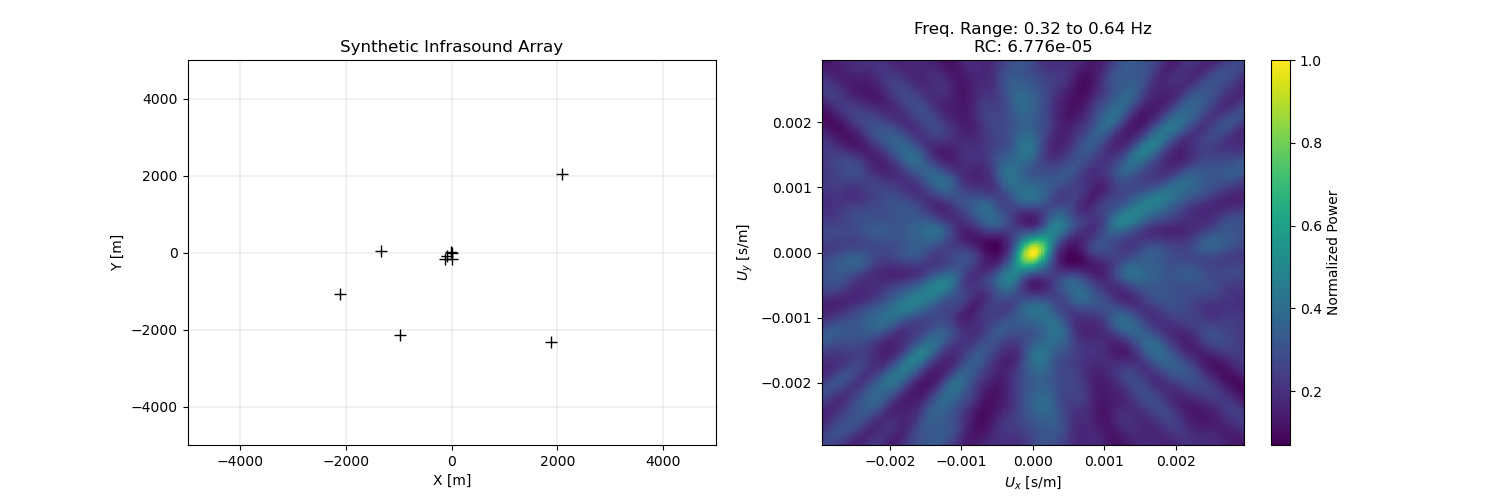

In [56]:
freqmin = 0.32; freqmax=0.64
geometry, relative_geometry, labels = make_synthetic_array(randomize=False, num_stns=10)
array_resp, p_x, p_y, array_resp_max = cardinal.array_response(relative_geometry[:,0], relative_geometry[:,1], freqmin=freqmin, freqmax=freqmax, c_app=340, c_steps=200, freqsteps=50)
#-----------------------------------------------------------------------------------------------------------------#
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(relative_geometry[:,0], relative_geometry[:,1], '+', color='black', markersize=8)
axs[0].set_title('Synthetic Infrasound Array')
axs[0].set_xlabel('X [m]'); axs[0].set_ylabel('Y [m]')
axs[0].set_xlim([-5000,5000]); axs[0].set_ylim([-5000,5000])
axs[0].grid(lw=0.25)
# Plot array response
pcolor = axs[1].pcolormesh(p_x, p_y, array_resp, cmap='viridis')
cbar = plt.colorbar(pcolor, label='Normalized Power')
axs[1].set_xlabel(r'$U_{x}$ [s/m]'); axs[1].set_ylabel(r'$U_{y}$ [s/m]')
mean_tmp = np.mean(array_resp); std_tmp = np.std(array_resp)
plt.title('Freq. Range: %.2f'%freqmin + ' to %.2f'%freqmax + ' Hz\nRC: '+ format(((mean_tmp + std_tmp) / array_resp_max), ".3e"))

---
Seismic Example

Text(0.5, 1.0, 'Freq. Range: 1.28 to 2.56 Hz\nRC: 4.290e-05')

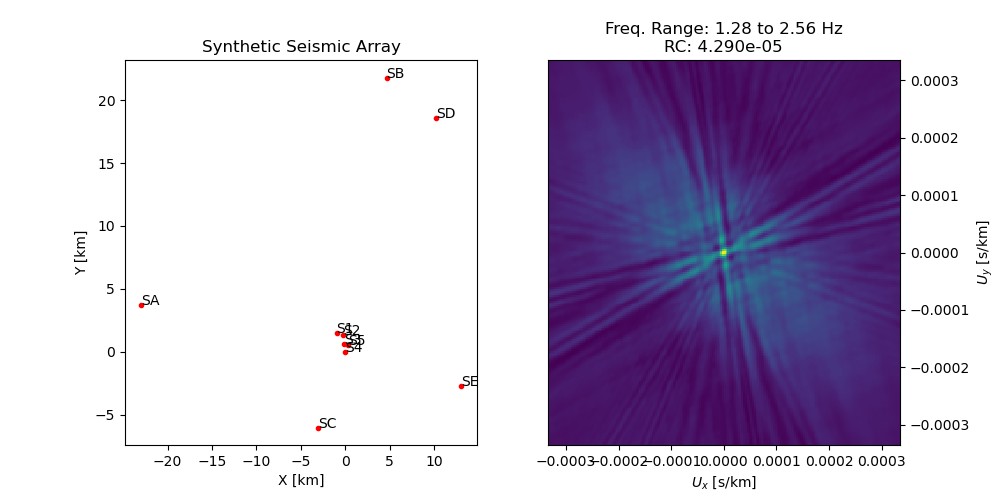

In [224]:
freqmin = 1.28; freqmax=2.56
geometry, relative_geometry, labels = make_synthetic_array(small_arr_extent=2, large_arr_extent=50, randomize=False)
array_resp, p_x, p_y, array_resp_max = cardinal.array_response(relative_geometry[:,0], relative_geometry[:,1], freqmin=freqmin, freqmax=freqmax, c_app=3000, c_steps=200, freqsteps=50)
#-----------------------------------------------------------------------------------------------------------------#
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(relative_geometry[:,0]/1000, relative_geometry[:,1]/1000, 'r.', markersize=6)
for i in range(0,len(labels)):
    axs[0].text(relative_geometry[i,0]/1000, relative_geometry[i,1]/1000, labels[i])
axs[0].set_title('Synthetic Seismic Array')
axs[0].set_xlabel('X [km]'); axs[0].set_ylabel('Y [km]')
# Plot array response
axs[1].pcolormesh(p_x, p_y, array_resp, cmap='viridis')
axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()
axs[1].set_xlabel(r'$U_{x}$ [s/km]'); axs[1].set_ylabel(r'$U_{y}$ [s/km]')
mean_tmp = np.mean(array_resp); std_tmp = np.std(array_resp)
plt.title('Freq. Range: %.2f'%freqmin + ' to %.2f'%freqmax + ' Hz\nRC: '+ format(((mean_tmp + std_tmp) / array_resp_max), ".3e"))

Text(0.5, 1.0, 'Freq. Range: 1.28 to 2.56 Hz\nRC: 4.624e-05')

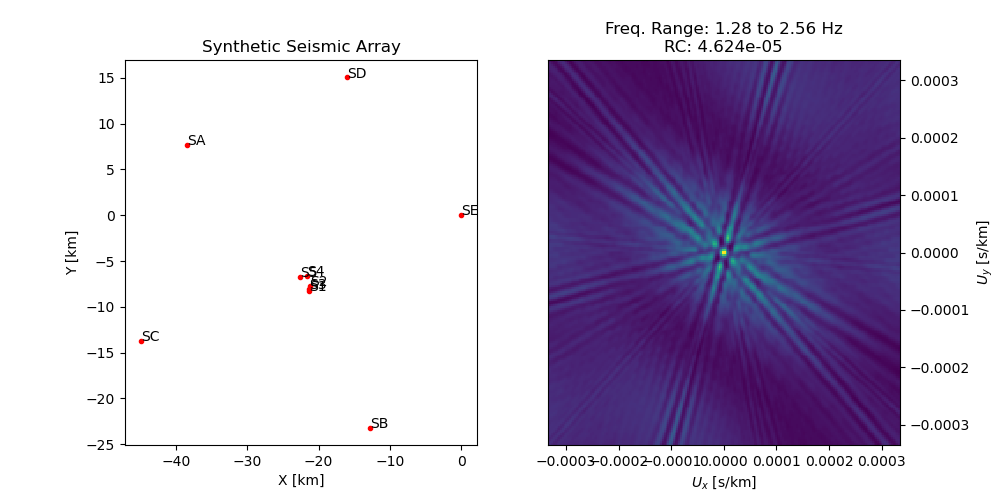

In [226]:
freqmin = 1.28; freqmax=2.56
geometry, relative_geometry, labels = make_synthetic_array(small_arr_extent=2, large_arr_extent=50, randomize=False)
array_resp, p_x, p_y, array_resp_max = cardinal.array_response(relative_geometry[:,0], relative_geometry[:,1], freqmin=freqmin, freqmax=freqmax, c_app=3000, c_steps=200, freqsteps=50)
#-----------------------------------------------------------------------------------------------------------------#
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(relative_geometry[:,0]/1000, relative_geometry[:,1]/1000, 'r.', markersize=6)
for i in range(0,len(labels)):
    axs[0].text(relative_geometry[i,0]/1000, relative_geometry[i,1]/1000, labels[i])
axs[0].set_title('Synthetic Seismic Array')
axs[0].set_xlabel('X [km]'); axs[0].set_ylabel('Y [km]')
# Plot array response
axs[1].pcolormesh(p_x, p_y, array_resp, cmap='viridis')
axs[1].yaxis.set_label_position("right")
axs[1].yaxis.tick_right()
axs[1].set_xlabel(r'$U_{x}$ [s/km]'); axs[1].set_ylabel(r'$U_{y}$ [s/km]')
mean_tmp = np.mean(array_resp); std_tmp = np.std(array_resp)
plt.title('Freq. Range: %.2f'%freqmin + ' to %.2f'%freqmax + ' Hz\nRC: '+ format(((mean_tmp + std_tmp) / array_resp_max), ".3e"))